INSTALL LIBRARIES

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade matplotlib pandas

IMPORT LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

READ DATA WITH PANDAS

In [3]:
df = pd.read_csv("data\sales.csv", encoding="utf-8", header=0 )
df.info()

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2404\3847603031.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv("data\sales.csv", encoding="utf-8", header=0 )


<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


PANDAS SETTINGS

In [7]:
df.Date = pd.to_datetime(df.Date, format='%d-%m-%Y') #Make date column to datetime instead of str. Giving the date format of the csv
print (df.Date.dtype)
pd.set_option('display.float_format', lambda x: '{:,.2f}' .format(x))

datetime64[us]


Create Year, Day and Month columns to work with

In [5]:
df['Day'] = df.Date.dt.day_name() #Create: df['column_name']. Read:df.column_name
df['Month'] = df.Date.dt.month
df['Year'] = df.Date.dt.year

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Day,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.57,211.10,8.11,Friday,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.55,211.24,8.11,Friday,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.51,211.29,8.11,Friday,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.56,211.32,8.11,Friday,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.62,211.35,8.11,Friday,3,2010


Analysis

Sales x Month

Month
1    332,598,438.49
2    568,727,890.45
3    592,785,901.28
4    646,859,784.97
5    557,125,571.95
6    622,629,886.84
7    650,000,977.25
8    613,090,208.82
9    578,761,179.26
10   584,784,787.59
11   413,015,725.01
12   576,838,635.20
Name: Weekly_Sales, dtype: float64


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '11'),
  Text(11, 0, '12')])

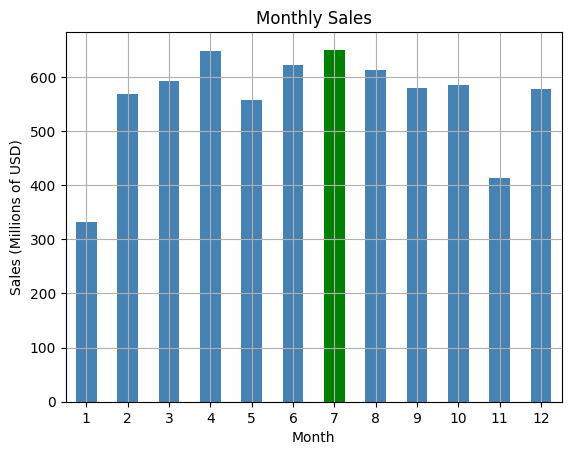

In [17]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()  # group the sales by month and return the total
top_month = monthly_sales.max()
worst_month = monthly_sales.min()

print(monthly_sales)

# Graph
colors = ['green' if v == top_month else 'steelblue' for v in monthly_sales]
(monthly_sales/1000000).plot(kind='bar', title='Monthly Sales', ylabel='Sales (Millions of USD)', xlabel='Month', color=colors, grid= True)
plt.xticks(rotation=0)